In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
def cross_matrix(vec):
    return np.array([[0, -vec[2], vec[1]],
                      [vec[2], 0, -vec[0]],
                      [-vec[1], vec[0], 0]])

def uncross_matrix(mat):
    return np.array([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def omega_dot(t, omega, I_B):
    skew_omega= cross_matrix(omega)
    return -np.linalg.inv(I_B) @ (skew_omega @ I_B @ omega)
    

In [8]:
omega1 = np.array([.9,.1,0])
omega2 = np.array([0.1,0.9,0])

I_B = np.array([[10, 0, 0],
                [0,  5, 0],
                [0,  0, 1]], dtype=float)


time = np.linspace(0,10,1000)
sol1 = solve_ivp(lambda t, y: omega_dot(t,y,I_B),   # pass function, not its output
                [0,10], omega1,
                t_eval=time,
                atol=1e-8, rtol=1e-8)
sol2 = solve_ivp(lambda t, y: omega_dot(t,y,I_B),   # pass function, not its output
                [0,10], omega2,
                t_eval=time,
                atol=1e-8, rtol=1e-8)
omegadot_sol1 = sol1.y
omegadot_sol2 = sol2.y


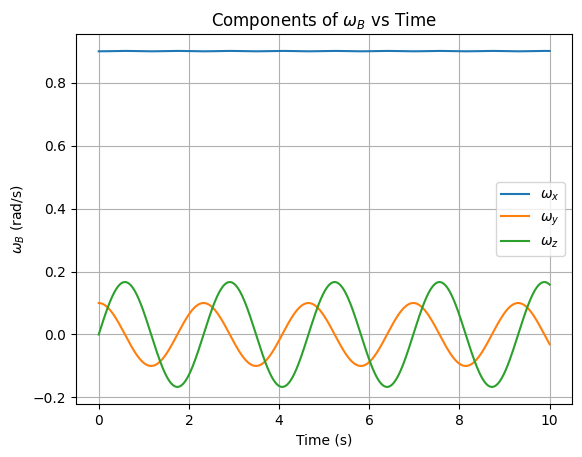

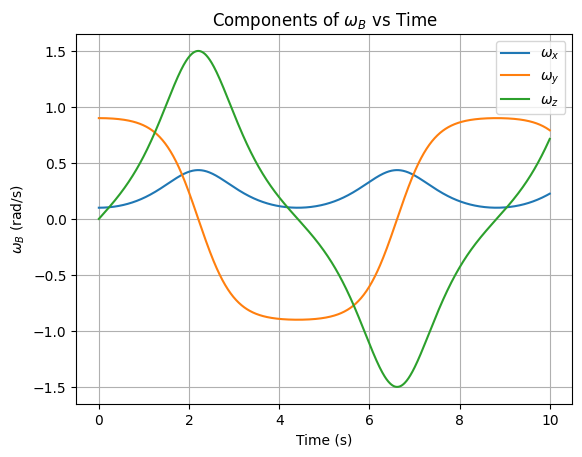

In [11]:
# --- Plot 1: omega1 components vs time ---
plt.figure(1)
plt.clf()
plt.plot(sol1.t, omegadot_sol1[0,:], label=r'$\omega_x$')
plt.plot(sol1.t, omegadot_sol1[1,:], label=r'$\omega_y$')
plt.plot(sol1.t, omegadot_sol1[2,:], label=r'$\omega_z$')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_B$ (rad/s)')
plt.title(r'Components of $\omega_B$ vs Time')
plt.legend()
plt.grid(True)
plt.show()
# --- Plot 2: omega2 components vs time ---
plt.figure(2)
plt.clf()
plt.plot(sol2.t, omegadot_sol2[0,:], label=r'$\omega_x$')
plt.plot(sol2.t, omegadot_sol2[1,:], label=r'$\omega_y$')
plt.plot(sol2.t, omegadot_sol2[2,:], label=r'$\omega_z$')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_B$ (rad/s)')
plt.title(r'Components of $\omega_B$ vs Time')
plt.legend()
plt.grid(True)
plt.show()


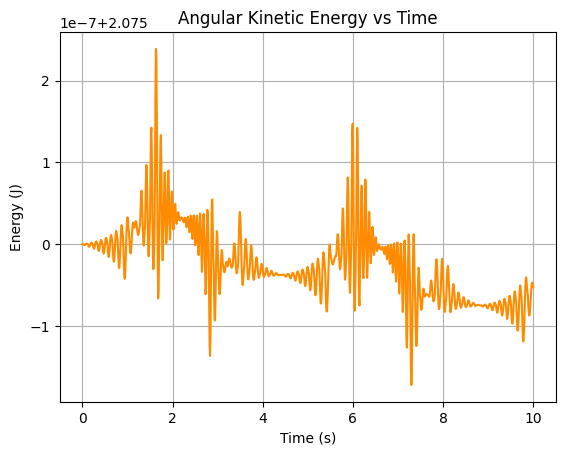

In [14]:
# --- Plot 2: Angular kinetic energy vs time ---
# T = 0.5 * omega^T @ I_B @ omega
T = 0.5 * np.einsum('ij,jk,ki->i', omega_sol.T, I_B, omega_sol)

plt.figure(2)
plt.clf()
plt.plot(sol.t, T, color='darkorange')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Angular Kinetic Energy vs Time')
plt.grid(True)
plt.show()

In [54]:
# Problem 3 Euler-Lagrange Simulation
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
m1 = symbols("m1",  positive=True)   # mass of each body-link end mass
m2 = symbols("m2",  positive=True)   # mass at tip of extendable leg
w  = symbols("w",   positive=True)   # half-width of body link
g  = symbols("g",   positive=True)   # gravitational acceleration
omega = symbols("omega", positive=True)  # forcing frequency
# Config Variables
x     = Function('x',     real=True)(t)
y     = Function('y',     real=True)(t)
theta1= Function('theta1', real=True)(t)
theta2= Function('theta2',real=True)(t)
phi   = Function('phi',   real=True)(t)
l     = Function('l',     real=True)(t)

In [124]:
# Defining Various Helper Functions
def cross_matrix(vec):
    
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m


In [125]:
# T_world_to_body: translate to (x,y), rotate by theta
T1 = T(R_z(theta1), Matrix([[0],[0],[0]])) @ T(Matrix.eye(3,3), Matrix([[x],[y],[0]]))
T1 = simplify(T1)

# T Matrix to Right and Left Masses
T1_right = T1 @ T(Matrix.eye(3,3), Matrix([[w],[0],[0]]))
T1_right = simplify(T1_right)
T1_left  = T1 @ T(Matrix.eye(3,3), Matrix([[-w],[0],[0]]))
T1_left = simplify(T1_left)

# T_body_to_leg: no translation (leg attaches at same joint), rotate by phi
T2 = T1 @ T(R_z(theta2), Matrix([[0],[0],[0]])) @ T(Matrix.eye(3,3), Matrix([[0],[0],[-l]]))
T2 = simplify(T2)

In [126]:
bodytwist_r = simplify(T1_right.inv() @ diff(T1_right, t))  # for right m1
bodytwist_l = simplify(T1_left.inv() @ diff(T1_left, t))  # for left m1
bodytwist_2 = simplify(T2.inv() @ diff(T2, t))  # for m2

b_r = twist2vec(bodytwist_r)
b_l = twist2vec(bodytwist_l)
b_2 = twist2vec(bodytwist_2)

In [127]:
b_r

⎡                   0                   ⎤
⎢                                       ⎥
⎢                   0                   ⎥
⎢                                       ⎥
⎢               d                       ⎥
⎢               ──(θ₁(t))               ⎥
⎢               dt                      ⎥
⎢                                       ⎥
⎢             d           d             ⎥
⎢      - y(t)⋅──(θ₁(t)) + ──(x(t))      ⎥
⎢             dt          dt            ⎥
⎢                                       ⎥
⎢  d                d           d       ⎥
⎢w⋅──(θ₁(t)) + x(t)⋅──(θ₁(t)) + ──(y(t))⎥
⎢  dt               dt          dt      ⎥
⎢                                       ⎥
⎣                   0                   ⎦

In [128]:
b_l

⎡                    0                    ⎤
⎢                                         ⎥
⎢                    0                    ⎥
⎢                                         ⎥
⎢                d                        ⎥
⎢                ──(θ₁(t))                ⎥
⎢                dt                       ⎥
⎢                                         ⎥
⎢              d           d              ⎥
⎢       - y(t)⋅──(θ₁(t)) + ──(x(t))       ⎥
⎢              dt          dt             ⎥
⎢                                         ⎥
⎢    d                d           d       ⎥
⎢- w⋅──(θ₁(t)) + x(t)⋅──(θ₁(t)) + ──(y(t))⎥
⎢    dt               dt          dt      ⎥
⎢                                         ⎥
⎣                    0                    ⎦

In [129]:
b_2

⎡                                                0                                                ⎤
⎢                                                                                                 ⎥
⎢                                                0                                                ⎥
⎢                                                                                                 ⎥
⎢                                      d           d                                              ⎥
⎢                                      ──(θ₁(t)) + ──(θ₂(t))                                      ⎥
⎢                                      dt          dt                                             ⎥
⎢                                                                                                 ⎥
⎢                d                           d                      d                     d       ⎥
⎢x(t)⋅sin(θ₂(t))⋅──(θ₁(t)) - y(t)⋅cos(θ₂(t))⋅──(θ₁(t)) + sin(θ₂(t))⋅──(y(t)) + cos(θ₂(t))⋅──(x(t))⎥


In [130]:
Gb1=Matrix([[0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,m1,0,0],
           [0,0,0,0,m1,0],
           [0,0,0,0,0,m1]])
     
Gb2=Matrix([[0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,m2,0,0],
           [0,0,0,0,m2,0],
           [0,0,0,0,0,m2]])
KEl=simplify(.5*b_l.T @ Gb1 @ b_l)[0]
KEr=simplify(.5*b_r.T @ Gb1 @ b_r)[0]
KE2=simplify(.5*b_2.T @ Gb2 @ b_2)[0]
KE_tot= simplify(KEl + KEr + KE2)

In [131]:
KE_tot

In [137]:
V = m1*g*T1_right[1,3] + m1*g*T1_left[1,3] + m2*g*T2[1,3]
V

In [138]:
L=KE_tot-V
L

In [142]:
q      = [x, y, theta1, theta2, l]
q_dt   = [diff(qi, t)    for qi in q]
q_dtdt = [diff(qi, t, t) for qi in q]

EOM_list = []
for qi in q:
    eq = diff(diff(L, diff(qi, t)), t) - diff(L, qi)
    EOM_list.append(nsimplify(eq))

H    = Matrix([[eq] for eq in EOM_list])
mass = simplify(H.jacobian(q_dtdt))
EOM  = simplify(H - mass * Matrix(q_dtdt))
EOM

⎡                                                                                                    2                 ↪
⎢                                                                                         ⎛d        ⎞         d        ↪
⎢                                         2⋅g⋅m₁⋅sin(θ₁(t)) + g⋅m₂⋅sin(θ₁(t)) - 2⋅m₁⋅x(t)⋅⎜──(θ₁(t))⎟  - 4⋅m₁⋅──(θ₁(t) ↪
⎢                                                                                         ⎝dt       ⎠         dt       ↪
⎢                                                                                                                      ↪
⎢                                                                                                    2                 ↪
⎢                                                                                         ⎛d        ⎞         d        ↪
⎢                                         2⋅g⋅m₁⋅cos(θ₁(t)) + g⋅m₂⋅cos(θ₁(t)) - 2⋅m₁⋅y(t)⋅⎜──(θ₁(t))⎟  + 4⋅m₁⋅──(θ₁(t) ↪
⎢                               

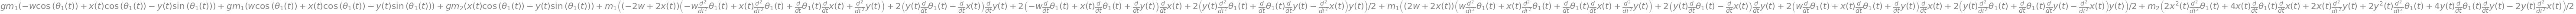

In [139]:
EOM_theta1= diff(diff(L,Derivative(theta1,t)),t)-diff(L,theta1)
EOM_theta1=nsimplify(EOM_theta1)
EOM_theta1

In [140]:
EOM_theta2= diff(diff(L,Derivative(theta2,t)),t)-diff(L,theta2)
EOM_theta2=nsimplify(EOM_theta2)
EOM_theta2

In [143]:
T2

⎡cos(θ₁(t) + θ₂(t))  -sin(θ₁(t) + θ₂(t))  0  x(t)⋅cos(θ₁(t)) - y(t)⋅sin(θ₁(t))⎤
⎢                                                                             ⎥
⎢sin(θ₁(t) + θ₂(t))  cos(θ₁(t) + θ₂(t))   0  x(t)⋅sin(θ₁(t)) + y(t)⋅cos(θ₁(t))⎥
⎢                                                                             ⎥
⎢        0                    0           1                -l(t)              ⎥
⎢                                                                             ⎥
⎣        0                    0           0                  1                ⎦